# Wine Quality Prediction - Exploratory Data Analysis

**Dataset:** WineQT.csv (a variant of the UCI Red Wine Quality dataset)
**Goal:** Explore, understand, and document the structure and patterns in the wine
physicochemical data before moving on to preprocessing and model building for a
wine quality prediction task.

This notebook performs EDA only — no feature engineering decisions are finalized
and no machine learning models are trained here.


## 1. Introduction

Wine quality is influenced by a combination of physicochemical properties measured
during production and testing — acidity, sugar, sulfur compounds, density, pH,
alcohol content, and more. Each wine sample in this dataset has been scored by
wine tasters on a quality scale.

**Objective of this notebook:**
- Understand the structure, quality, and distribution of the dataset.
- Identify data quality issues (missing values, duplicates, invalid entries).
- Explore the target variable (`quality`) and its balance.
- Study individual features (univariate analysis) and their relationship with
  `quality` (bivariate analysis).
- Examine correlations between features and flag potential multicollinearity.
- Identify outliers and discuss whether they should be retained for modeling.
- Summarize key findings to guide the upcoming preprocessing and modeling stage.

**Important notes:**
- `quality` is the **target variable** for the eventual prediction task.
- `Id` is purely a row identifier and carries no predictive signal — it is
  excluded from all statistical/visual feature analysis.
- The original dataset is never modified in this notebook.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

In [2]:
# Load the raw dataset. The original file/DataFrame is never modified in-place;
# any transformation used purely for a plot is done on a copy or a temporary series.
df = pd.read_csv("WineQT.csv")
print(f"Dataset loaded successfully with shape: {df.shape}")

Dataset loaded successfully with shape: (1143, 13)


## 4. Dataset Overview

### 4.1 Shape of the dataset

In [3]:
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 1143
Number of columns : 13


**Observation:** The dataset contains 1,143 wine samples (fewer than the classic
1,599-row Red Wine Quality dataset — this `WineQT.csv` variant is a subset), each
described by 11 physicochemical features, 1 target column (`quality`), and 1 `Id` column.


### 4.2 Column names and data types

In [4]:
info_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values
})
display(info_df)

,Column,Dtype,Non-Null Count
0,fixed acidity,float64,1143
1,volatile acidity,float64,1143
2,citric acid,float64,1143
3,residual sugar,float64,1143
4,chlorides,float64,1143
5,free sulfur dioxide,float64,1143
6,total sulfur dioxide,float64,1143
7,density,float64,1143
8,pH,float64,1143
9,sulphates,float64,1143


### 4.3 First and last few rows

In [5]:
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
display(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


### 4.4 Feature descriptions

| Column | Description |
|---|---|
| `fixed acidity` | Tartaric-acid-based acids that do not evaporate easily (g/dm³). |
| `volatile acidity` | Acetic acid content (g/dm³); too high a level produces an unpleasant, vinegar-like taste. |
| `citric acid` | Found in small quantities; can add freshness and flavor to the wine. |
| `residual sugar` | Amount of sugar remaining after fermentation stops (g/dm³). |
| `chlorides` | Amount of salt in the wine. |
| `free sulfur dioxide` | The free form of SO₂, which prevents microbial growth and wine oxidation. |
| `total sulfur dioxide` | Total amount of free + bound SO₂; noticeable in taste/smell at high concentrations. |
| `density` | Density of the wine, related to alcohol and sugar content. |
| `pH` | Describes how acidic/basic the wine is on a 0 (very acidic) to 14 (very basic) scale; most wines fall between 3 and 4. |
| `sulphates` | A wine additive that contributes to SO₂ levels and acts as an antimicrobial/antioxidant. |
| `alcohol` | Percentage alcohol content of the wine. |
| `quality` | **Target variable.** Quality score (integer, typically 0–10) based on sensory data from wine tasters. |
| `Id` | Unique row identifier — **not a predictive feature**, kept only for record-keeping/traceability. |


## 5. Data Quality Checks

### 5.1 Missing / null values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df)

,Missing Count,Missing %
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [8]:
print(f"Total missing values in the dataset: {df.isnull().sum().sum()}")

Total missing values in the dataset: 0


**Observation:** There are no missing values in any column — the dataset is complete.

### 5.2 Duplicate rows

In [9]:
full_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {full_duplicates}")

Number of fully duplicated rows: 0


### 5.3 Duplicate IDs

In [10]:
duplicate_ids = df["Id"].duplicated().sum()
print(f"Number of duplicate Id values: {duplicate_ids}")
print(f"Number of unique Id values   : {df['Id'].nunique()} out of {len(df)} rows")

Number of duplicate Id values: 0
Number of unique Id values   : 1143 out of 1143 rows


### 5.4 Inconsistent or invalid values

In [11]:
numeric_cols_all = df.columns.drop("Id")

# 1) Check for negative values in columns where negatives are physically impossible
negative_counts = (df[numeric_cols_all] < 0).sum()
print("Negative-value counts per column (should all be 0):")
print(negative_counts[negative_counts.index != "quality"])

Negative-value counts per column (should all be 0):
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64


In [12]:
# 2) Sanity-check the quality score range
print("Quality score range in the data :", df["quality"].min(), "-", df["quality"].max())
print("Unique quality values           :", sorted(df["quality"].unique()))

Quality score range in the data : 3 - 8
Unique quality values           : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [13]:
# 3) Check pH is within a chemically plausible range for wine (roughly 2.5 - 4.5)
out_of_range_ph = df[(df["pH"] < 2.5) | (df["pH"] > 4.5)]
print(f"Rows with pH outside the typical 2.5-4.5 wine range: {len(out_of_range_ph)}")

Rows with pH outside the typical 2.5-4.5 wine range: 0


In [14]:
# 4) Check alcohol percentage is within a plausible range for wine (roughly 8% - 15%)
out_of_range_alcohol = df[(df["alcohol"] < 8) | (df["alcohol"] > 15)]
print(f"Rows with alcohol % outside the typical 8-15 range: {len(out_of_range_alcohol)}")

Rows with alcohol % outside the typical 8-15 range: 0


### 5.5 Summary of data quality findings

- **Missing values:** None — every column is fully populated.
- **Duplicate rows:** None found.
- **Duplicate IDs:** None — `Id` is a clean, unique identifier for every row.
- **Negative values:** None in any physicochemical column (as expected, since none of
  these measurements can physically be negative).
- **Quality range:** Scores range from 3 to 8 (not the full 0–10 scale), meaning the
  dataset does not contain any extremely poor (0–2) or perfect (9–10) wines.
- **pH / alcohol ranges:** Values fall within chemically plausible bounds for wine,
  with no obviously invalid entries.

**Overall, this dataset is clean** — no imputation, deduplication, or invalid-value
correction is required before analysis.


## 6. Descriptive Statistics

### 6.1 Summary statistics for numerical columns

In [15]:
feature_cols = df.columns.drop(["Id"])  # keep quality here for completeness of the stats table
display(df[feature_cols].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,1143.0,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,1143.0,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,1143.0,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,1143.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1143.0,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,1143.0,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,1143.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1143.0,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,1143.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


### 6.2 Range and spread of each feature

In [16]:
range_df = pd.DataFrame({
    "min": df[feature_cols].min(),
    "max": df[feature_cols].max(),
    "range": df[feature_cols].max() - df[feature_cols].min(),
    "mean": df[feature_cols].mean().round(3),
    "median": df[feature_cols].median(),
    "std": df[feature_cols].std().round(3),
    "skew": df[feature_cols].skew().round(3)
})
display(range_df)

,min,max,range,mean,median,std,skew
fixed acidity,4.60000,15.90000,11.30000,8.311,7.90000,1.748,1.045
volatile acidity,0.12000,1.58000,1.46000,0.531,0.52000,0.180,0.682
citric acid,0.00000,1.00000,1.00000,0.268,0.25000,0.197,0.372
residual sugar,0.90000,15.50000,14.60000,2.532,2.20000,1.356,4.361
chlorides,0.01200,0.61100,0.59900,0.087,0.07900,0.047,6.026
free sulfur dioxide,1.00000,68.00000,67.00000,15.615,13.00000,10.250,1.231
total sulfur dioxide,6.00000,289.00000,283.00000,45.915,37.00000,32.782,1.666
density,0.99007,1.00369,0.01362,0.997,0.99668,0.002,0.102
pH,2.74000,4.01000,1.27000,3.311,3.31000,0.157,0.221
sulphates,0.33000,2.00000,1.67000,0.658,0.62000,0.170,2.497


**Observations:**

- **Skewed distributions:** `residual sugar`, `chlorides`, `free sulfur dioxide`,
  `total sulfur dioxide`, and `sulphates` show strong positive (right) skew — a small
  number of high-value samples pull the mean above the median.
- **Fairly symmetric features:** `density` and `pH` are close to normally distributed
  (skew near 0), consistent with them being tightly regulated chemical properties.
- **Wide-ranging features:** `total sulfur dioxide` and `free sulfur dioxide` have the
  largest absolute ranges among the physicochemical variables, reflecting real
  variability in preservative treatment across wine batches.
- **`quality`** is a discrete, narrow-range variable (3-8) with most mass concentrated
  around 5-6, which we explore in detail in Section 7.


## 7. Target Variable Analysis

### 7.1 Frequency of each quality score

In [17]:
quality_counts = df["quality"].value_counts().sort_index()
quality_pct = (quality_counts / len(df) * 100).round(2)
quality_summary = pd.DataFrame({"Count": quality_counts, "Percentage": quality_pct})
display(quality_summary)

,Count,Percentage
quality,,
3,6,0.52
4,33,2.89
5,483,42.26
6,462,40.42
7,143,12.51
8,16,1.40


### 7.2 Distribution of the target variable

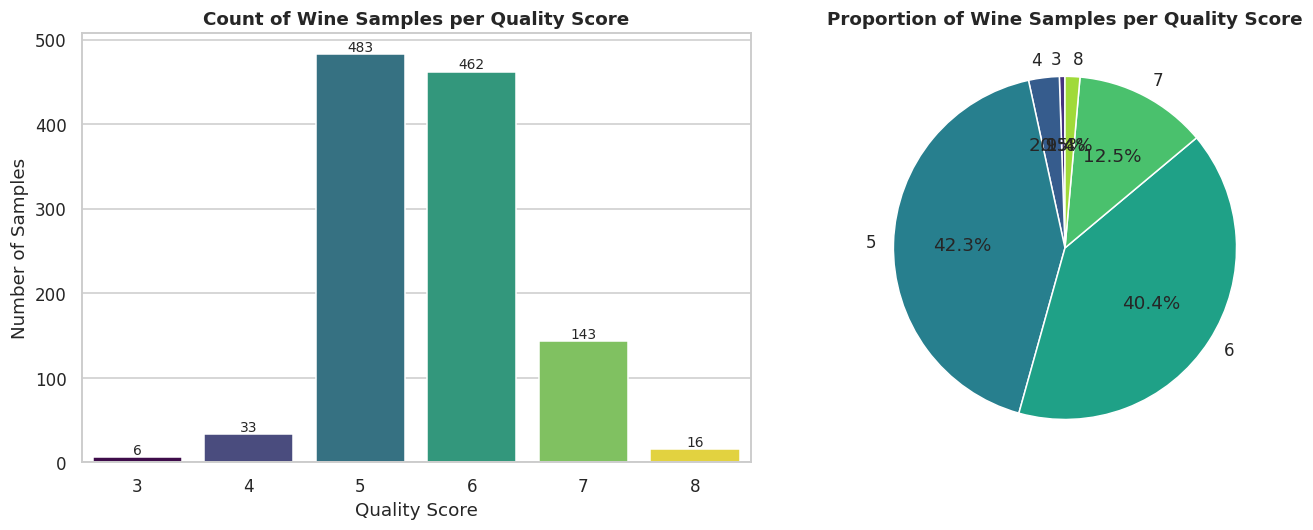

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x="quality", data=df, ax=axes[0], hue="quality", legend=False, palette="viridis")
axes[0].set_title("Count of Wine Samples per Quality Score")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Number of Samples")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontsize=9)

axes[1].pie(quality_counts, labels=quality_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", len(quality_counts)), startangle=90)
axes[1].set_title("Proportion of Wine Samples per Quality Score")

plt.tight_layout()
plt.show()

### 7.3 Is the target balanced or imbalanced?

**The target variable `quality` is clearly imbalanced.** Quality scores 5 and 6 together
account for roughly 83% of all samples, while the extreme classes (3, 4, 7, 8) are
comparatively rare — quality 3 and quality 8 each make up under 1.5% of the data. This
has direct implications for later modeling:

- A model could achieve deceptively high accuracy by simply predicting 5 or 6 for
  every sample.
- Techniques such as class weighting, resampling (SMOTE/oversampling), stratified
  train/test splitting, or treating this as an ordinal regression problem should be
  considered at the modeling stage.
- Evaluation should rely on metrics beyond plain accuracy (e.g., macro-F1, confusion
  matrix, balanced accuracy) given the class imbalance.


## 8. Univariate Analysis

We now examine the individual distribution of each numerical feature
(excluding `Id`, which is not a meaningful feature). For every feature we plot a
histogram (with a KDE curve) alongside a boxplot to jointly reveal shape, spread,
and potential outliers.


In [19]:
numeric_features = [c for c in df.columns if c not in ["Id", "quality"]]
print("Numerical features analyzed:", numeric_features)

Numerical features analyzed: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 8.1 Histograms and boxplots for all numerical features

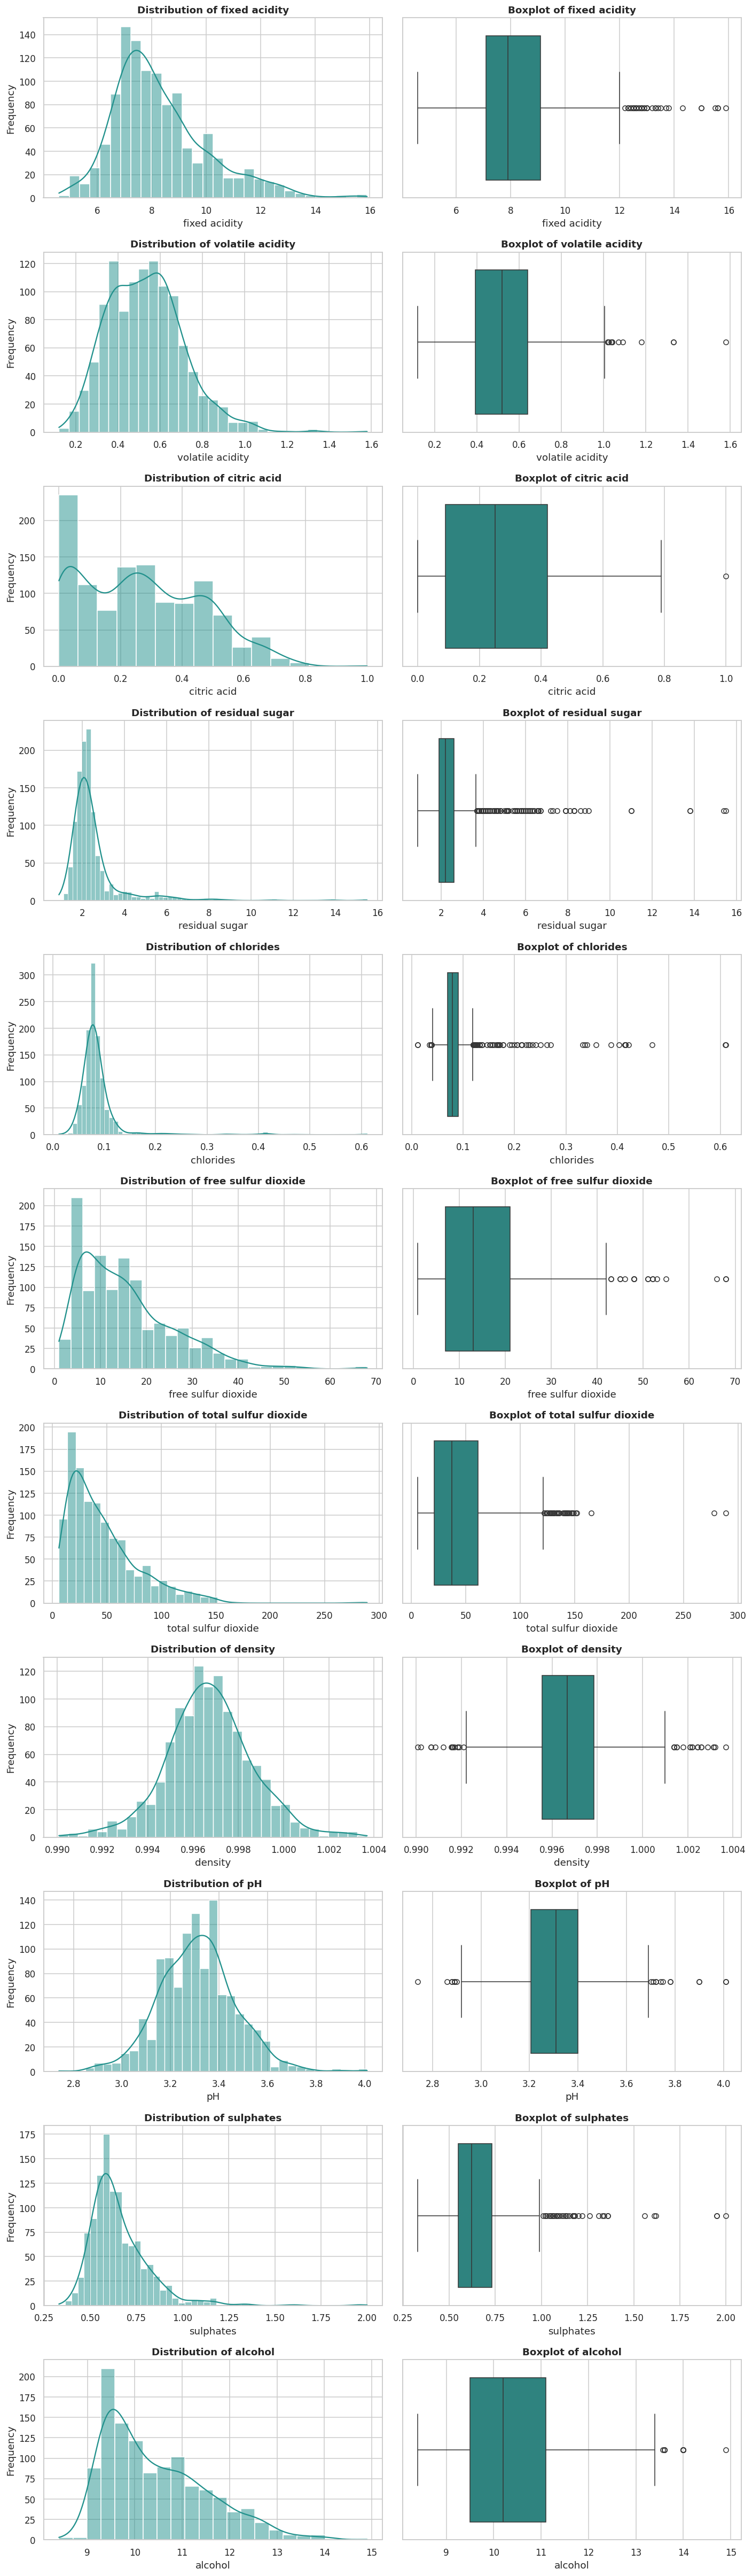

In [20]:
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color=sns.color_palette("viridis", 1)[0])
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")

    sns.boxplot(x=df[col], ax=axes[i, 1], color=sns.color_palette("viridis", 3)[1])
    axes[i, 1].set_title(f"Boxplot of {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

**Key observations from the univariate plots:**

- **`fixed acidity`, `volatile acidity`, `citric acid`:** Moderately right-skewed;
  `citric acid` has a spike at 0, suggesting many wines contain little to no citric acid.
- **`residual sugar` and `chlorides`:** Strongly right-skewed with a long tail and a
  visible cluster of high-value outliers in the boxplot — most wines have low sugar
  and chloride content, with a handful of much sweeter/saltier exceptions.
- **`free sulfur dioxide` and `total sulfur dioxide`:** Right-skewed distributions with
  several high outliers; total SO₂ naturally trends higher than free SO₂ since it
  includes the bound fraction.
- **`density` and `pH`:** Approximately bell-shaped/near-normal, with few outliers —
  consistent with these being tightly controlled physical/chemical properties.
- **`sulphates`:** Right-skewed with a number of upper outliers.
- **`alcohol`:** Right-skewed, concentrated between roughly 9% and 12%, with a tail
  extending toward higher-alcohol wines.

Overall, most features are **not normally distributed** — several show clear right
skew and boxplot outliers, which is expected for real-world chemical measurement data
and is addressed further in Section 11 (Outlier Analysis).


## 9. Bivariate Analysis

We now study how each physicochemical feature relates to the target variable
`quality`, using boxplots to compare feature distributions across quality scores.


### 9.1 Feature distributions across quality scores (boxplots)

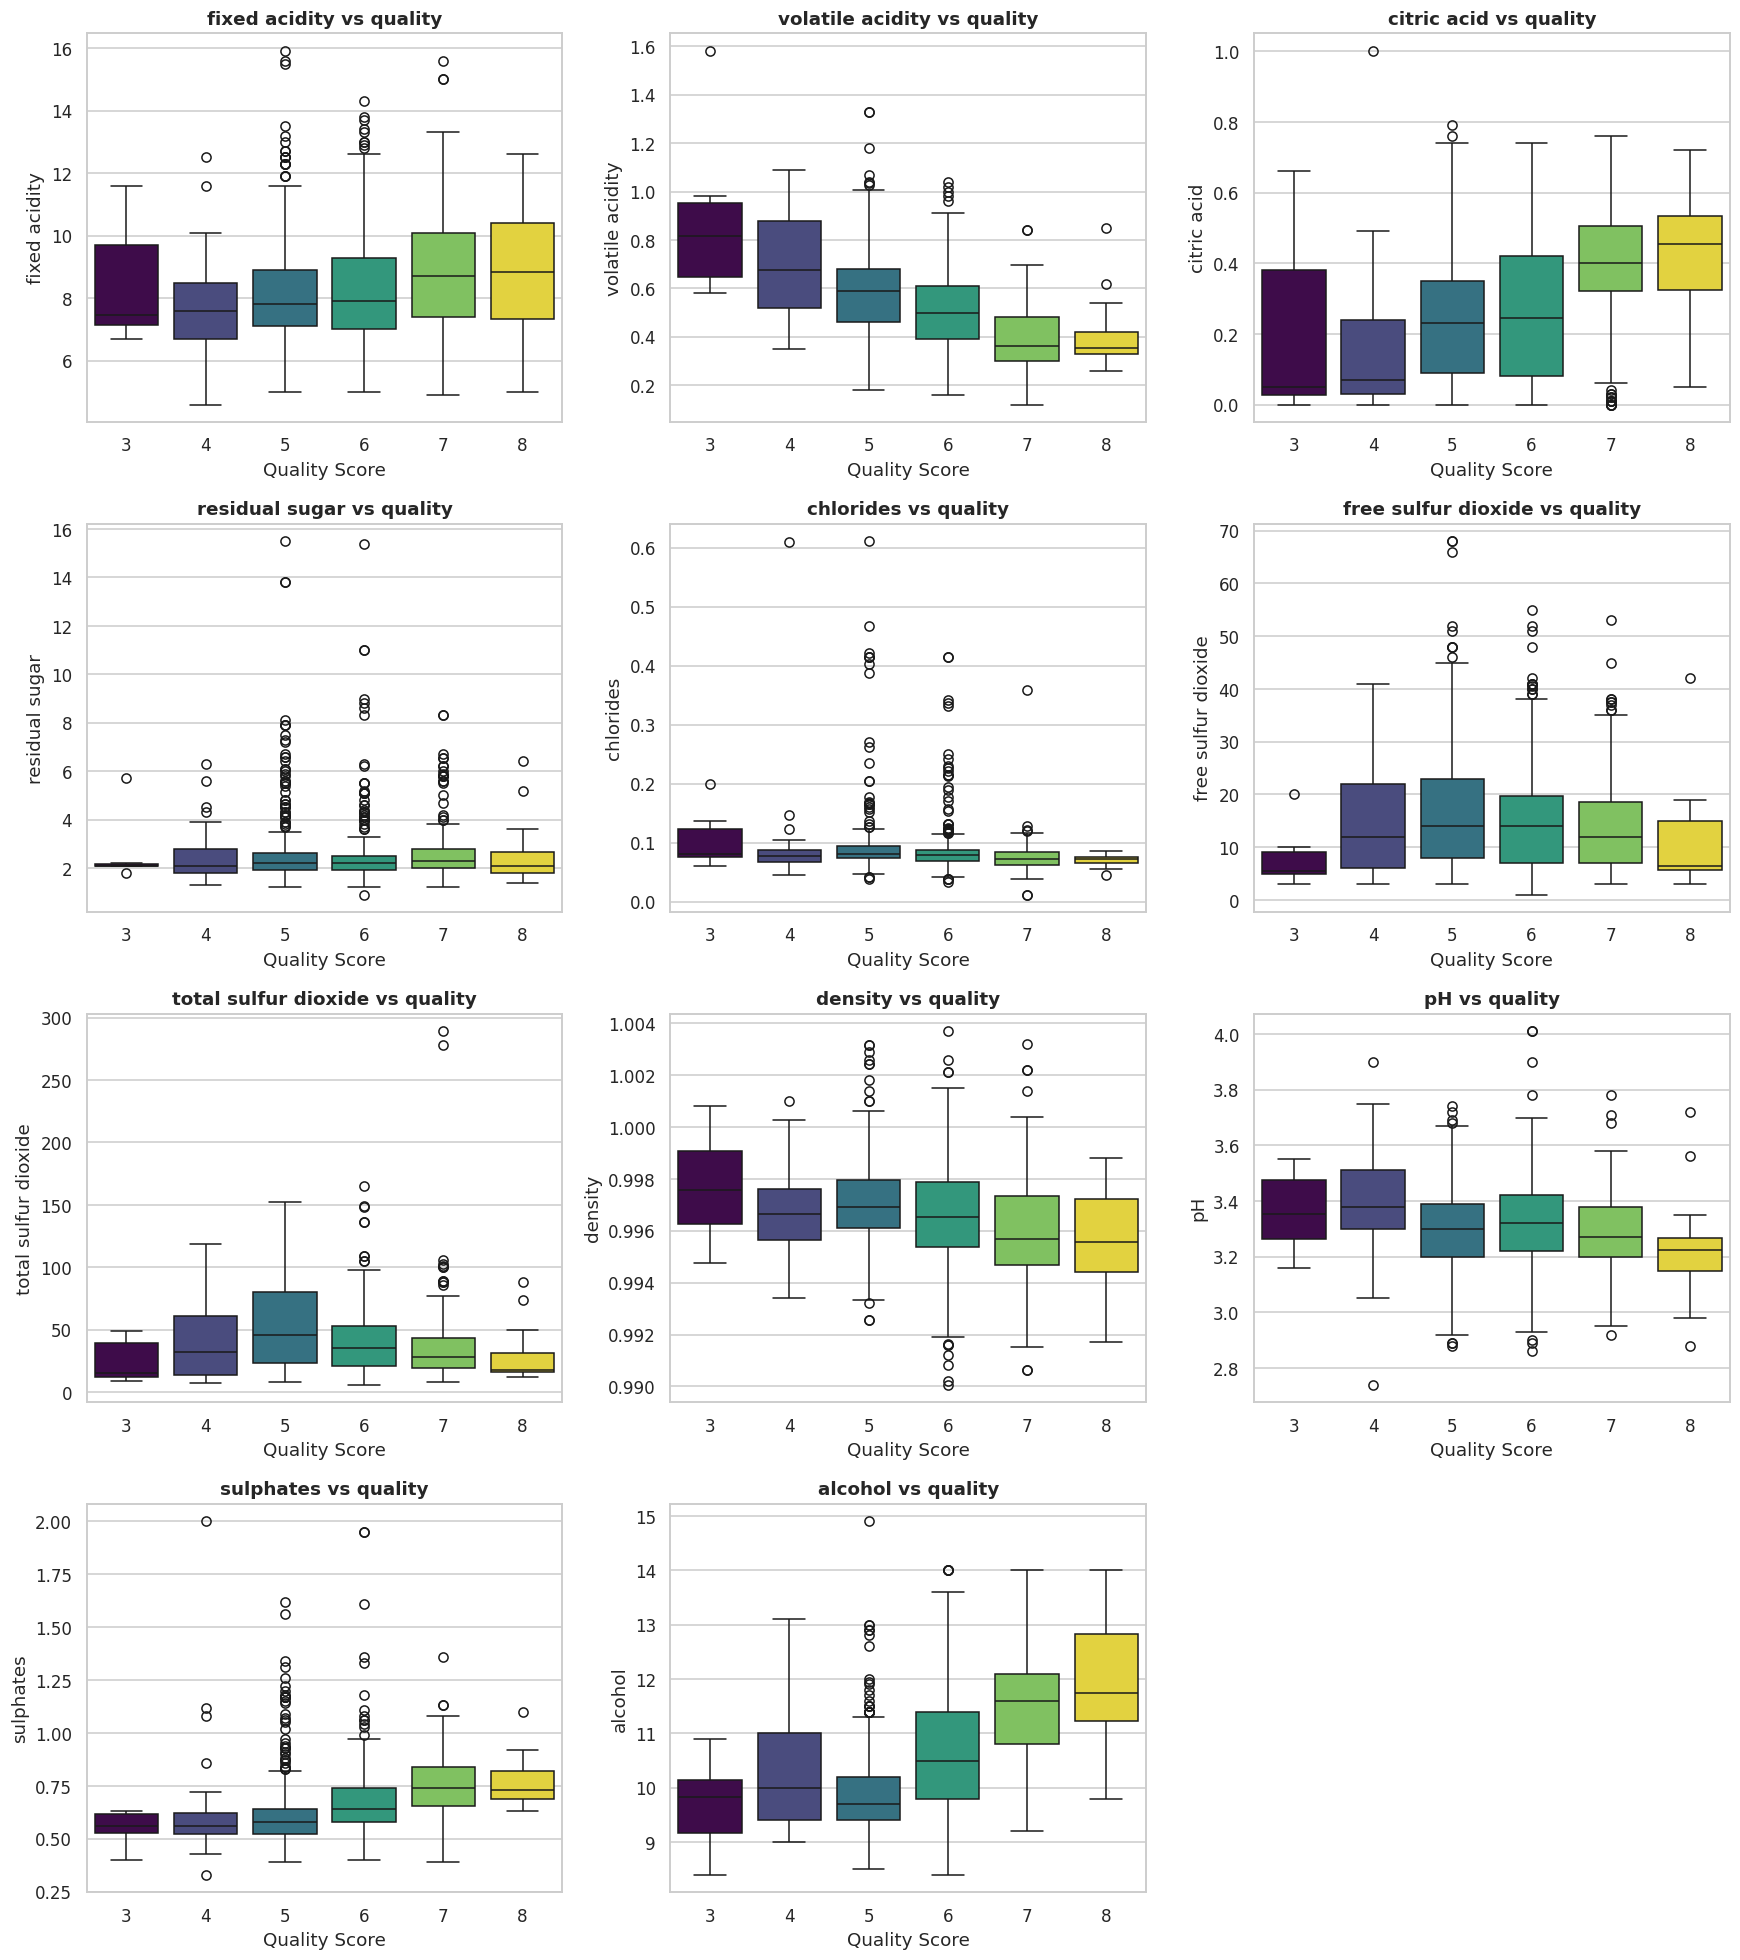

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x="quality", y=col, data=df, ax=axes[i], hue="quality", legend=False, palette="viridis")
    axes[i].set_title(f"{col} vs quality")
    axes[i].set_xlabel("Quality Score")
    axes[i].set_ylabel(col)

# Hide any unused subplot axes
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 9.2 Alcohol and volatile acidity vs quality (violin plots)

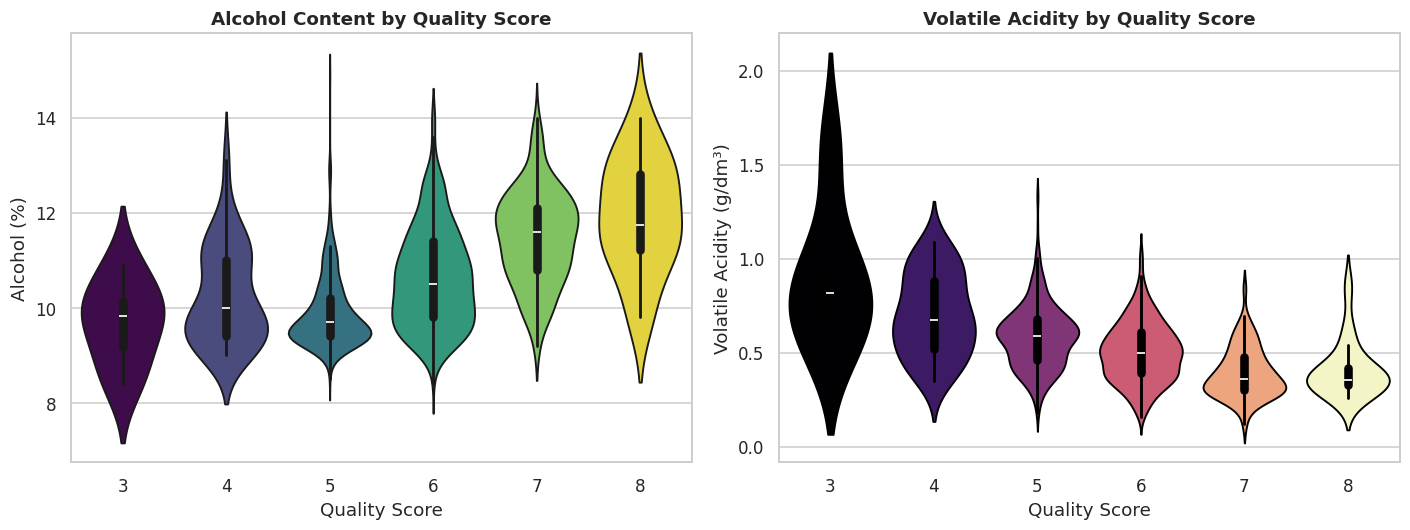

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(x="quality", y="alcohol", data=df, ax=axes[0], hue="quality", legend=False, palette="viridis")
axes[0].set_title("Alcohol Content by Quality Score")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Alcohol (%)")

sns.violinplot(x="quality", y="volatile acidity", data=df, ax=axes[1], hue="quality", legend=False, palette="magma")
axes[1].set_title("Volatile Acidity by Quality Score")
axes[1].set_xlabel("Quality Score")
axes[1].set_ylabel("Volatile Acidity (g/dm³)")

plt.tight_layout()
plt.show()

### 9.3 Alcohol vs volatile acidity, colored by quality (scatter plot)

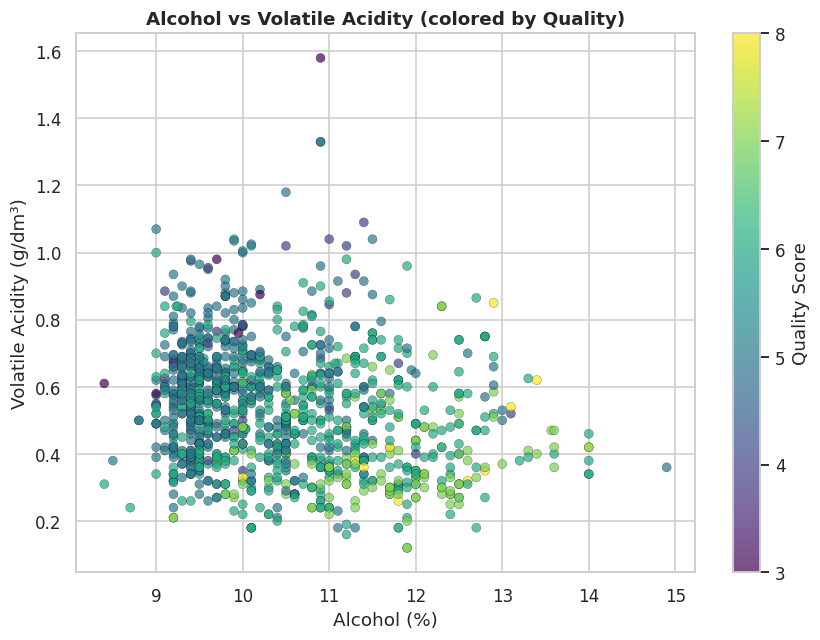

In [23]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["alcohol"], df["volatile acidity"], c=df["quality"],
                       cmap="viridis", alpha=0.7, s=35, edgecolor="k", linewidth=0.2)
plt.colorbar(scatter, label="Quality Score")
plt.title("Alcohol vs Volatile Acidity (colored by Quality)")
plt.xlabel("Alcohol (%)")
plt.ylabel("Volatile Acidity (g/dm³)")
plt.tight_layout()
plt.show()

### 9.4 Mean feature value by quality score

In [24]:
mean_by_quality = df.groupby("quality")[numeric_features].mean().round(3)
display(mean_by_quality)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450,0.898,0.212,2.667,0.105,8.167,24.500,0.998,3.362,0.550,9.692
4,7.809,0.700,0.166,2.567,0.095,14.848,40.606,0.997,3.391,0.638,10.261
5,8.161,0.585,0.240,2.540,0.092,16.613,55.299,0.997,3.302,0.613,9.902
6,8.318,0.505,0.264,2.445,0.085,15.215,39.942,0.997,3.324,0.677,10.655
7,8.851,0.394,0.387,2.760,0.075,14.538,37.490,0.996,3.287,0.744,11.483
8,8.806,0.410,0.432,2.644,0.070,11.062,29.375,0.996,3.241,0.766,11.938


**Key observations from the bivariate analysis:**

- **`alcohol`** shows the clearest positive relationship with `quality` — higher-quality
  wines (7, 8) tend to have noticeably higher alcohol content than lower-quality wines
  (3, 4, 5).
- **`volatile acidity`** shows a clear negative relationship — higher-quality wines
  tend to have lower volatile acidity, consistent with the fact that high acetic-acid
  content produces an unpleasant, vinegar-like taste.
- **`sulphates`** shows a mild positive trend with quality — higher sulphate levels are
  somewhat more common in better-rated wines.
- **`citric acid`** shows a mild positive relationship with quality as well.
- **`density`, `pH`, `residual sugar`, `free/total sulfur dioxide`, `chlorides`, and
  `fixed acidity`** show weak or unclear relationships with quality on their own —
  their medians shift only slightly across quality levels, and their boxplots overlap
  heavily between adjacent quality groups.
- The scatter plot confirms that a combination of **high alcohol and low volatile
  acidity** is visually associated with better-quality wines (darker/yellow points
  cluster at the bottom-right), suggesting these two variables may be especially
  useful jointly for prediction.

Overall, **`alcohol` and `volatile acidity` appear to have the strongest relationships
with wine quality** among all measured features, a pattern we verify quantitatively in
the correlation analysis below.


## 10. Correlation Analysis

### 10.1 Correlation matrix

In [25]:
corr_matrix = df.drop(columns=["Id"]).corr()
display(corr_matrix.round(2))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.25,0.67,0.17,0.11,-0.16,-0.11,0.68,-0.69,0.17,-0.08,0.12
volatile acidity,-0.25,1.00,-0.54,-0.01,0.06,-0.00,0.08,0.02,0.22,-0.28,-0.20,-0.41
citric acid,0.67,-0.54,1.00,0.18,0.25,-0.06,0.04,0.38,-0.55,0.33,0.11,0.24
residual sugar,0.17,-0.01,0.18,1.00,0.07,0.17,0.19,0.38,-0.12,0.02,0.06,0.02
chlorides,0.11,0.06,0.25,0.07,1.00,0.02,0.05,0.21,-0.28,0.37,-0.23,-0.12
free sulfur dioxide,-0.16,-0.00,-0.06,0.17,0.02,1.00,0.66,-0.05,0.07,0.03,-0.05,-0.06
total sulfur dioxide,-0.11,0.08,0.04,0.19,0.05,0.66,1.00,0.05,-0.06,0.03,-0.19,-0.18
density,0.68,0.02,0.38,0.38,0.21,-0.05,0.05,1.00,-0.35,0.14,-0.49,-0.18
pH,-0.69,0.22,-0.55,-0.12,-0.28,0.07,-0.06,-0.35,1.00,-0.19,0.23,-0.05
sulphates,0.17,-0.28,0.33,0.02,0.37,0.03,0.03,0.14,-0.19,1.00,0.09,0.26


### 10.2 Correlation heatmap

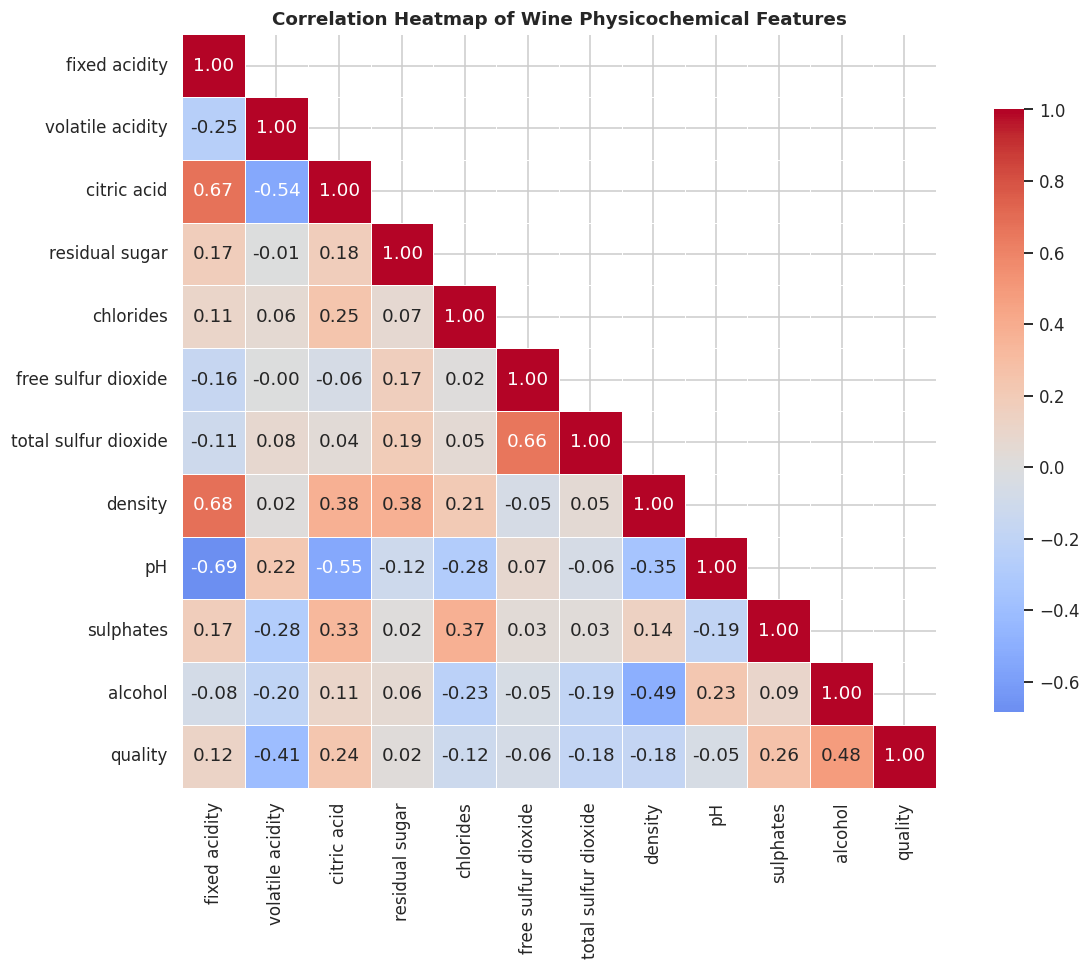

In [26]:
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Wine Physicochemical Features")
plt.tight_layout()
plt.show()

### 10.3 Correlation of each feature with quality

In [27]:
quality_corr = corr_matrix["quality"].drop("quality").sort_values(ascending=False)
display(quality_corr.to_frame(name="Correlation with quality"))

,Correlation with quality
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260
chlorides,-0.124085
density,-0.175208
total sulfur dioxide,-0.183339


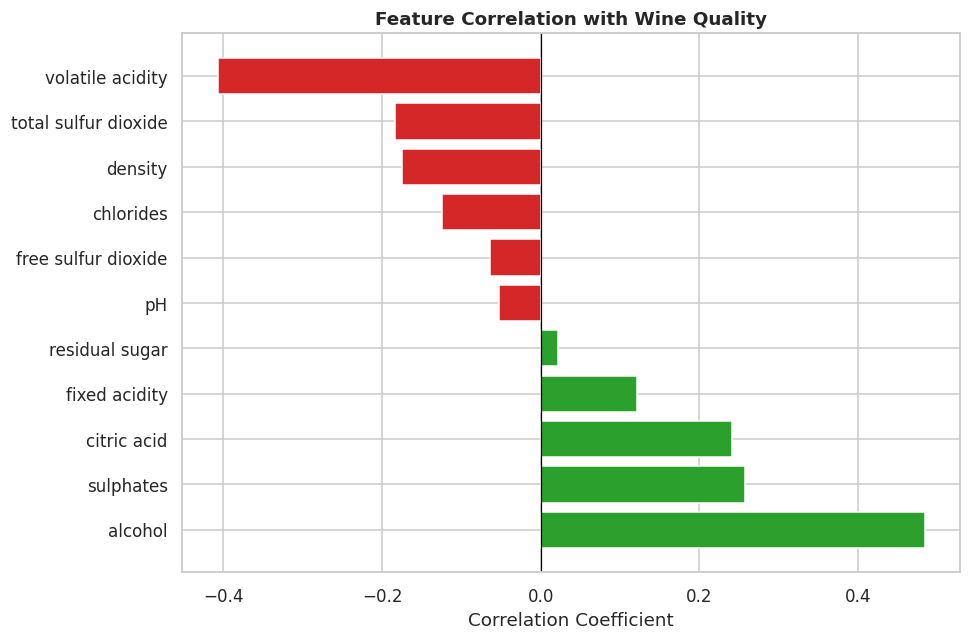

In [28]:
plt.figure(figsize=(9, 6))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in quality_corr.values]
plt.barh(quality_corr.index, quality_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Wine Quality")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

**Correlation with `quality`:**

- **Strongest positive:** `alcohol` (r ≈ 0.48) is by far the strongest correlate of
  quality, followed by `sulphates` (r ≈ 0.26) and `citric acid` (r ≈ 0.24).
- **Strongest negative:** `volatile acidity` (r ≈ -0.41) is the strongest negative
  correlate, followed by `total sulfur dioxide` (r ≈ -0.18) and `density` (r ≈ -0.18).
- **Weak/near-zero correlations:** `residual sugar` (r ≈ 0.02), `pH` (r ≈ -0.05), and
  `free sulfur dioxide` (r ≈ -0.06) show almost no linear relationship with quality on
  their own — this doesn't rule out a non-linear or interaction effect, but a simple
  linear correlation finds little signal.

**Strongest pairwise correlations between features (potential multicollinearity):**

- `fixed acidity` & `density`: r ≈ 0.68 (strong positive)
- `fixed acidity` & `citric acid`: r ≈ 0.67 (strong positive)
- `free sulfur dioxide` & `total sulfur dioxide`: r ≈ 0.66 (strong positive, expected
  since total SO₂ includes the free fraction)
- `fixed acidity` & `pH`: r ≈ -0.69 (strong negative — makes chemical sense, since
  higher acid concentration generally lowers pH)
- `citric acid` & `pH`: r ≈ -0.55 (strong negative)
- `volatile acidity` & `citric acid`: r ≈ -0.54 (moderate negative)
- `density` & `alcohol`: r ≈ -0.49 (moderate negative)

These groups of strongly inter-correlated features (`fixed acidity`, `citric acid`,
`density`, `pH`; and separately `free sulfur dioxide` with `total sulfur dioxide`)
are candidates for multicollinearity checks (e.g. VIF) at the modeling stage.


## 11. Outlier Analysis

We use the **IQR (Interquartile Range) method** to flag potential outliers in
each numerical feature. A value is flagged if it falls below `Q1 - 1.5*IQR` or above
`Q3 + 1.5*IQR`. Note: this section only *identifies* outliers for discussion — no
rows are removed from the dataset.


In [29]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        rows.append({
            "Feature": col,
            "Lower Bound": round(lower_bound, 3),
            "Upper Bound": round(upper_bound, 3),
            "Outlier Count": len(outliers),
            "Outlier %": round(len(outliers) / len(data) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("Outlier Count", ascending=False).reset_index(drop=True)

outlier_summary = iqr_outlier_summary(df, numeric_features)
display(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,residual sugar,0.850,3.650,110,9.62
1,chlorides,0.040,0.120,77,6.74
2,fixed acidity,4.100,12.100,44,3.85
3,sulphates,0.280,1.000,43,3.76
4,total sulfur dioxide,-39.000,121.000,40,3.50
5,density,0.992,1.001,36,3.15
6,pH,2.913,3.692,20,1.75
7,free sulfur dioxide,-14.000,42.000,18,1.57
8,volatile acidity,0.021,1.011,14,1.22
9,alcohol,7.100,13.500,12,1.05


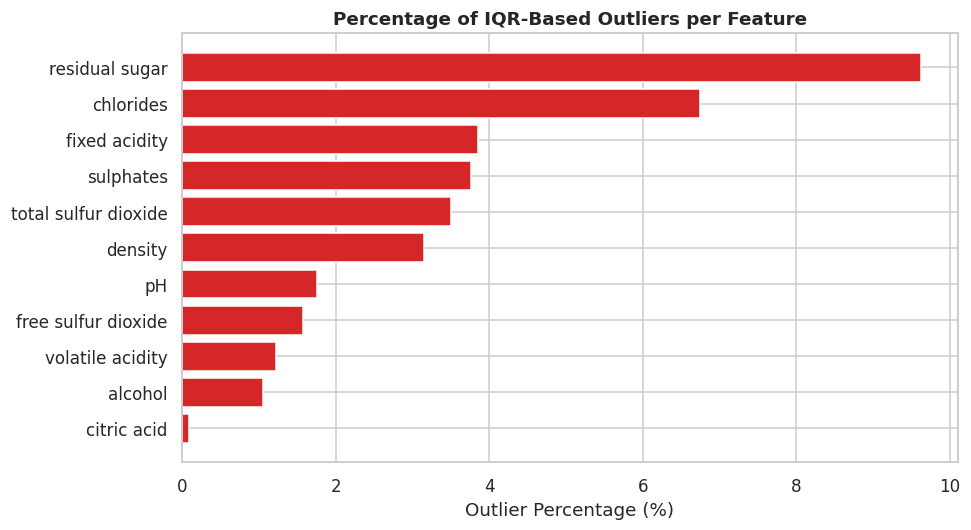

In [30]:
plt.figure(figsize=(9, 5))
plt.barh(outlier_summary["Feature"], outlier_summary["Outlier %"], color="#d62728")
plt.xlabel("Outlier Percentage (%)")
plt.title("Percentage of IQR-Based Outliers per Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:**

- **`residual sugar`** has the highest proportion of IQR-flagged outliers (~9.6% of
  rows), followed by **`chlorides`** (~6.7%) — consistent with their strong right skew
  seen in the univariate analysis.
- **`fixed acidity`, `sulphates`, `total sulfur dioxide`, and `density`** each have a
  moderate number of outliers (roughly 3-4% of rows).
- **`citric acid`** has almost no IQR outliers (~0.1%), and **`alcohol`** and
  **`volatile acidity`** — the two features most correlated with quality — have
  relatively few outliers (~1%) as well.

**Should these outliers be removed?**

**No — they should be retained at this stage**, for several reasons:

1. All flagged values are still **chemically plausible** measurements (e.g., a wine
   with unusually high residual sugar is simply a sweeter wine, not necessarily a data
   error) — none of the quality checks in Section 5 found invalid or impossible values.
2. Many "outlier" rows correspond to real, naturally occurring wine variation (e.g.,
   a few very sweet or very salty wine batches), and may carry useful signal about
   quality (e.g., unusually high sulphates or alcohol could be associated with
   higher-quality samples, as seen in Section 9).
3. With an already **imbalanced target** (Section 7.3), removing rows now — especially
   from the minority quality classes (3, 4, 8) — could further shrink already-small
   groups and hurt the model's ability to learn from them.
4. Outlier handling decisions (capping, transformation such as log-scaling for skewed
   features, or robust-scaling) are better made **during preprocessing**, informed by
   the specific model chosen, rather than by blanket removal during EDA.

The recommendation is to **flag and monitor** these outliers, and consider mild
treatments (e.g., log-transforming `residual sugar` and `chlorides`, or using
tree-based models that are naturally robust to outliers) later in the pipeline —
but not to delete the underlying data now.


## 12. Key EDA Findings

### 12.1 Data quality
- The dataset is **clean**: no missing values, no duplicate rows, and no duplicate
  `Id` values across 1,143 samples and 13 columns.
- All physicochemical measurements fall within plausible ranges — no negative values
  or clearly invalid entries were found.

### 12.2 Target variable (`quality`)
- `quality` is an **integer score ranging from 3 to 8** (not the full 0-10 scale).
- The target is **imbalanced**: quality 5 and 6 make up ~83% of the data, while
  quality 3 and 8 each represent under 1.5% of samples.
- This imbalance should be explicitly handled during train/test splitting (stratify)
  and model evaluation (avoid relying on plain accuracy).

### 12.3 Feature distributions
- Most features (`residual sugar`, `chlorides`, `free/total sulfur dioxide`,
  `sulphates`) are **right-skewed** with a meaningful share of statistical outliers.
- `density` and `pH` are close to normally distributed.
- `citric acid` has a notable spike of zero values.

### 12.4 Relationship with quality
- **`alcohol`** (r ≈ 0.48) and **`volatile acidity`** (r ≈ -0.41) are the two features
  most strongly (linearly) associated with wine quality — higher alcohol and lower
  volatile acidity are both associated with higher-quality wines.
- **`sulphates`** (r ≈ 0.26) and **`citric acid`** (r ≈ 0.24) show a moderate positive
  relationship with quality.
- **`residual sugar`, `pH`, and `free sulfur dioxide`** show almost no linear
  relationship with quality individually.

### 12.5 Multicollinearity risk (feature analysis)
- Several feature pairs are **highly correlated with each other** and are candidates
  for multicollinearity checks (e.g. Variance Inflation Factor) before/at model
  training:
  - `fixed acidity` ↔ `density` (r ≈ 0.68)
  - `fixed acidity` ↔ `citric acid` (r ≈ 0.67)
  - `fixed acidity` ↔ `pH` (r ≈ -0.69)
  - `citric acid` ↔ `pH` (r ≈ -0.55)
  - `free sulfur dioxide` ↔ `total sulfur dioxide` (r ≈ 0.66)
- **`alcohol` and `volatile acidity` appear especially useful for predicting quality**
  given their comparatively strong, consistent relationship with the target across
  both correlation analysis and bivariate plots; `sulphates` and `citric acid` are
  reasonable secondary candidates.
- No final feature-selection decision is made here — these are observations to guide,
  not replace, a proper feature-selection process (e.g. VIF analysis, model-based
  importance) during modeling.

### 12.6 Outliers
- IQR-based outliers are present in most features (most notably `residual sugar` and
  `chlorides`), but all values are chemically plausible and are **retained** for now;
  treatment (transformation, robust scaling, or model choice) is deferred to the
  preprocessing/modeling stage.

### 12.7 On `Id`
- `Id` is a unique row identifier with no relationship to wine chemistry or quality
  and has correctly been **excluded** from all statistical and visual analysis above.
  It should also be excluded from model training features.


## 13. Conclusion

This EDA shows that the WineQT dataset is clean, well-structured, and ready
for preprocessing. The clearest signal for predicting wine quality comes from
**alcohol content** (positive relationship) and **volatile acidity** (negative
relationship), supported to a lesser extent by **sulphates** and **citric acid**.
The target variable is **imbalanced**, and several features exhibit **skewed
distributions with outliers** that are best addressed through transformation or
model choice rather than deletion. A subset of features (`fixed acidity`,
`citric acid`, `density`, `pH`, and the two sulfur-dioxide measures) show strong
mutual correlation and warrant a multicollinearity check before finalizing the
feature set for modeling.

The next stage of this project should focus on: handling the target imbalance,
deciding on a treatment for skewed/outlier-heavy features, checking multicollinearity
formally (e.g., VIF), and then proceeding to model selection and training —
all of which fall outside the scope of this EDA notebook.


## EDA Summary — Key Takeaways for Preprocessing & Modeling

1. **Data is clean:** no missing values, no duplicate rows, no duplicate IDs, no
   invalid values. No imputation or deduplication needed.
2. **Target (`quality`) is imbalanced:** dominated by scores 5 and 6 (~83% combined);
   scores 3 and 8 are rare (<1.5% each). Use stratified splits and imbalance-aware
   evaluation metrics (macro-F1, confusion matrix) rather than plain accuracy.
   Consider treating this as ordinal regression, or grouping quality into broader
   bins (e.g., low/medium/high) if the classification task proves too fine-grained.
3. **Strongest predictors (by linear correlation with quality):**
   `alcohol` (+0.48), `volatile acidity` (-0.41), `sulphates` (+0.26), `citric acid`
   (+0.24). These are strong starting candidates for feature importance during
   modeling.
4. **Weak individual predictors:** `residual sugar`, `pH`, `free sulfur dioxide`
   show little linear relationship with quality alone but may still contribute via
   interactions or in tree-based/non-linear models.
5. **Multicollinearity risk:** `fixed acidity`, `citric acid`, `density`, and `pH`
   are highly inter-correlated, as are `free sulfur dioxide` and `total sulfur
   dioxide`. Run a VIF check before using linear models; consider dropping or
   combining redundant features if multicollinearity is confirmed.
6. **Skewed features with outliers:** `residual sugar`, `chlorides`,
   `free/total sulfur dioxide`, and `sulphates` are right-skewed with a meaningful
   share of IQR outliers. Consider log-transformation or robust scaling for these
   features if using models sensitive to scale/normality (e.g., linear/logistic
   regression, KNN, SVM); tree-based models (Random Forest, Gradient Boosting) are
   naturally more robust to this and may need less preprocessing here.
7. **No outliers were removed** in this notebook — all flagged values are plausible
   wine chemistry measurements, and removing them could further shrink an already
   small/imbalanced dataset.
8. **`Id` must be excluded** from the feature set used for model training — it is a
   row identifier with no predictive value.

These findings should directly inform the next steps: target-imbalance handling,
feature scaling/transformation choices, multicollinearity mitigation, and the choice
of baseline models for the wine quality prediction task.
